In [148]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import geopandas as gpd
from geobr import read_state
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [149]:
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DADOS_BRASIL = BASE_DIR / "dados" / "brasil"

ARQ_NASCIMENTOS = DADOS_BRASIL / "ano_nascimento.csv"

In [150]:
def ler_datasus(caminho):
    df = pd.read_csv(caminho, sep=";", encoding="latin1", skiprows=3, dtype=str)
    df = df.dropna(how="all")
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    return df

def limpar_nome_uf(valor):
    return str(valor).replace("..", "").strip()

def converter_colunas_numericas(df, colunas):
    for col in colunas:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace("-", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

In [151]:
nasc = ler_datasus(ARQ_NASCIMENTOS)

col_uf = "Região/Unidade da Federação"
anos = [str(ano) for ano in range(2000, 2025)]

nasc = nasc[[col_uf] + anos].copy()
nasc[col_uf] = nasc[col_uf].apply(limpar_nome_uf)
nasc = converter_colunas_numericas(nasc, anos)

ufs_excluir = [
    "Região Norte", "Região Nordeste", "Região Sudeste",
    "Região Sul", "Região Centro-Oeste", "Total", "nan"
]

nasc_uf = nasc[~nasc[col_uf].isin(ufs_excluir)].copy()
nasc_uf = nasc_uf.dropna(subset=["2000", "2024"])
nasc_uf = nasc_uf.rename(columns={col_uf: "UF"})

print("Número de UFs:", nasc_uf.shape[0])
nasc_uf.head()

Número de UFs: 27


,UF,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,Rondônia,31307.0,28236.0,29236.0,28809.0,28927.0,28081.0,24925.0,22996.0,26791.0,...,27918.0,26602.0,27503.0,28091.0,27028.0,25798.0,25439.0,24901.0,23921.0,21716.0
2,Acre,15228.0,14899.0,15841.0,15986.0,16584.0,17482.0,16448.0,16183.0,17994.0,...,16980.0,15773.0,16358.0,16543.0,16280.0,15142.0,15699.0,14483.0,14473.0,13101.0
3,Amazonas,67646.0,70252.0,70671.0,70751.0,71345.0,73488.0,75584.0,73469.0,75030.0,...,80097.0,76703.0,78066.0,78087.0,77622.0,75635.0,78454.0,72519.0,70453.0,65950.0
4,Roraima,9744.0,9600.0,8990.0,10160.0,9742.0,9694.0,9592.0,9582.0,10103.0,...,11412.0,11376.0,11737.0,13344.0,14620.0,13760.0,13901.0,13091.0,13105.0,12090.0
5,Pará,126340.0,134742.0,136000.0,144812.0,142894.0,145540.0,150202.0,150147.0,151262.0,...,143657.0,137681.0,138684.0,141819.0,138341.0,132938.0,137129.0,128000.0,126152.0,118566.0


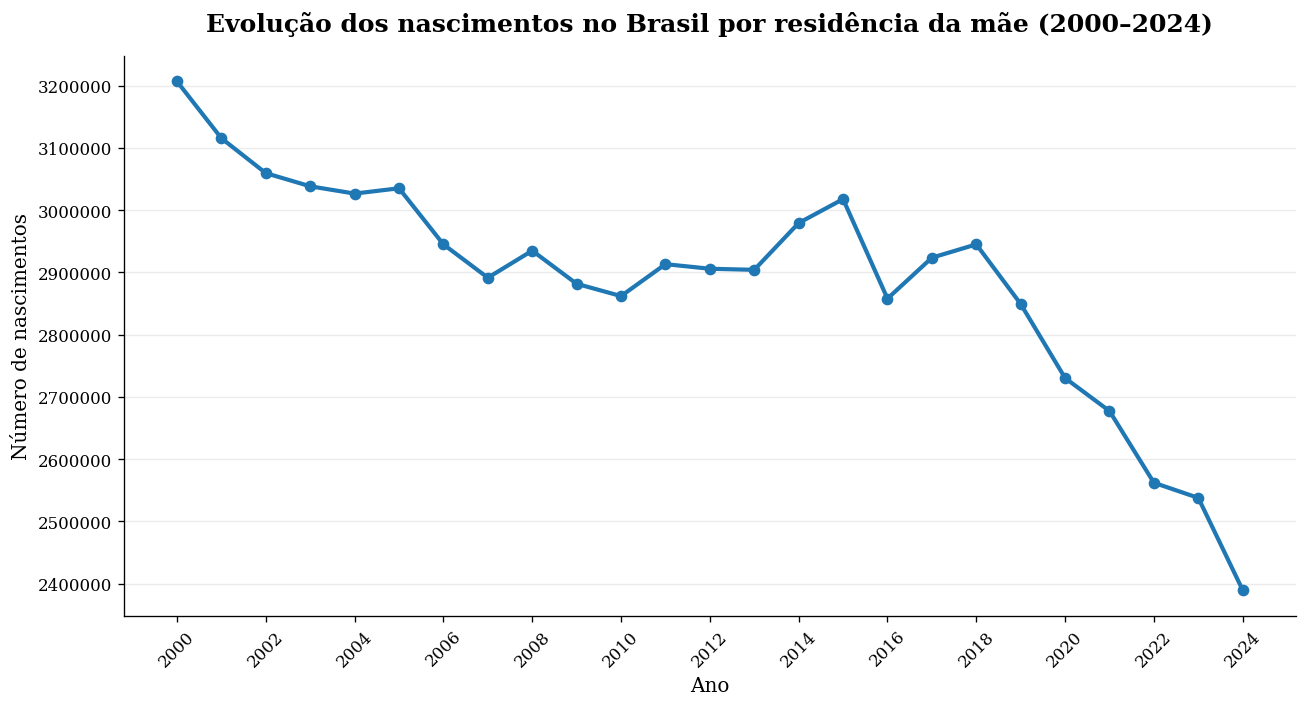

In [152]:
total_brasil = nasc_uf[anos].sum(axis=0).reset_index()
total_brasil.columns = ["Ano", "Nascimentos"]
total_brasil["Ano"] = total_brasil["Ano"].astype(int)

plt.figure(figsize=(11, 6))
plt.plot(total_brasil["Ano"], total_brasil["Nascimentos"], marker="o", linewidth=2.5)
plt.title("Evolução dos nascimentos no Brasil por residência da mãe (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de nascimentos", fontsize=12)
plt.xticks(range(2000, 2025, 2), rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

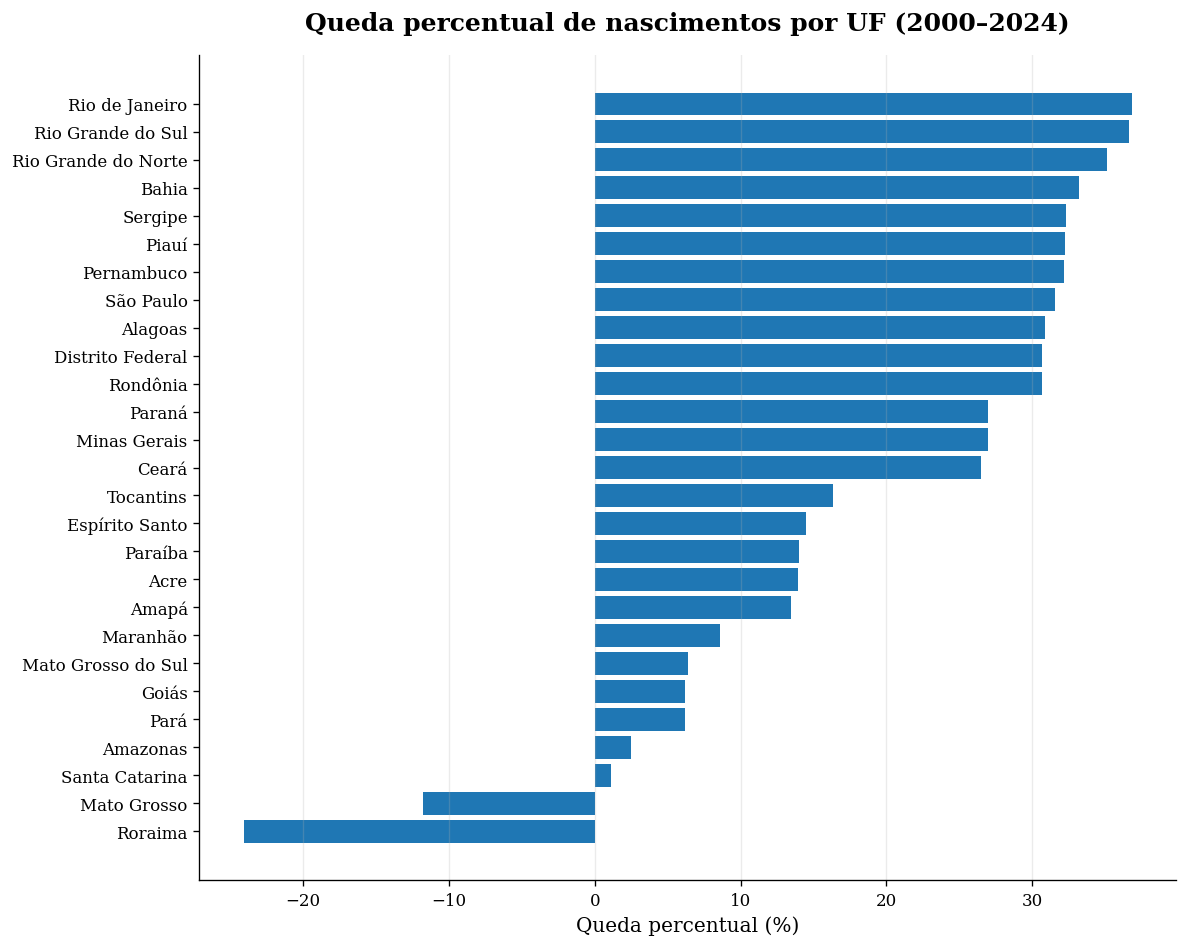

,UF,2000,2024,Queda_absoluta,Queda_percentual
21,Rio de Janeiro,259118.0,163722.0,95396.0,36.815659
26,Rio Grande do Sul,176719.0,111988.0,64731.0,36.629338
12,Rio Grande do Norte,56444.0,36612.0,19832.0,35.135710
17,Bahia,239530.0,160002.0,79528.0,33.201687
16,Sergipe,40716.0,27545.0,13171.0,32.348463
10,Piauí,58615.0,39697.0,18918.0,32.275015
14,Pernambuco,163405.0,110827.0,52578.0,32.176494
22,São Paulo,687779.0,470887.0,216892.0,31.535130
15,Alagoas,65763.0,45436.0,20327.0,30.909478
31,Distrito Federal,47991.0,33282.0,14709.0,30.649497


In [153]:
ranking_queda = nasc_uf[["UF", "2000", "2024"]].copy()
ranking_queda["Queda_absoluta"] = ranking_queda["2000"] - ranking_queda["2024"]
ranking_queda["Queda_percentual"] = (ranking_queda["Queda_absoluta"] / ranking_queda["2000"]) * 100
ranking_queda = ranking_queda.sort_values("Queda_percentual", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(ranking_queda["UF"], ranking_queda["Queda_percentual"])
plt.title("Queda percentual de nascimentos por UF (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Queda percentual (%)", fontsize=12)
plt.ylabel("")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

ranking_queda.sort_values("Queda_percentual", ascending=False).head(10)

In [154]:
valores_k = range(2, 9)

silhuetas = []
inercia = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = modelo.fit_predict(X_scaled)

    silhuetas.append(
        silhouette_score(X_scaled, labels)
    )

    inercia.append(
        modelo.inertia_
    )

avaliacao_k = pd.DataFrame({
    "k": list(valores_k),
    "Silhueta": silhuetas,
    "Inercia": inercia
})

melhor_k = int(
    avaliacao_k.loc[
        avaliacao_k["Silhueta"].idxmax(),
        "k"
    ]
)

print("Melhor k pela silhueta:", melhor_k)

avaliacao_k

Melhor k pela silhueta: 2


,k,Silhueta,Inercia
0,2,0.553116,227.327830
1,3,0.464201,162.876711
2,4,0.395717,123.879214
3,5,0.325713,98.546201
4,6,0.240495,83.511937
5,7,0.259438,70.612431
6,8,0.221918,56.114784


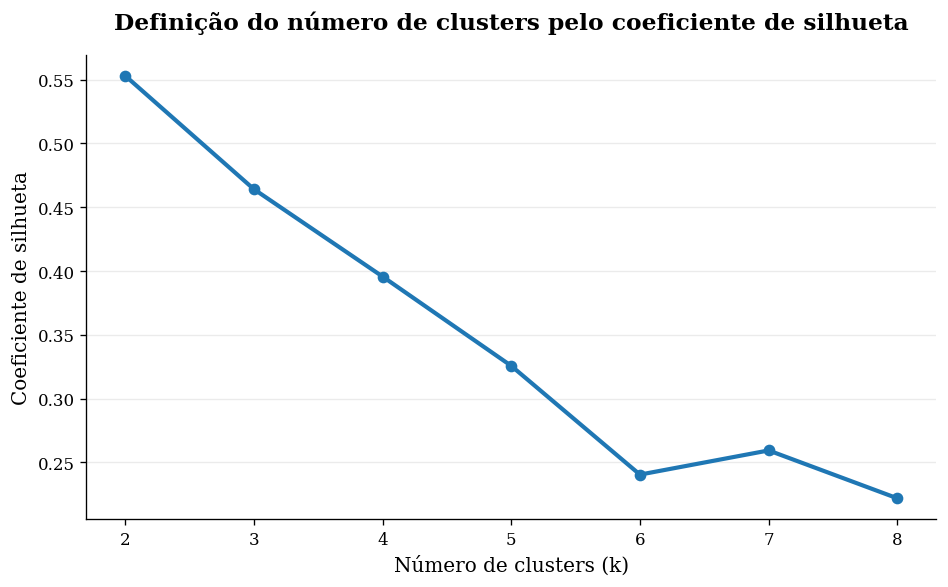

In [155]:
plt.figure(figsize=(8, 5))
plt.plot(silhueta_df["k"], silhueta_df["Silhueta"], marker="o", linewidth=2.5)
plt.title("Definição do número de clusters pelo coeficiente de silhueta", fontsize=14, weight="bold", pad=15)
plt.xlabel("Número de clusters (k)", fontsize=12)
plt.ylabel("Coeficiente de silhueta", fontsize=12)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

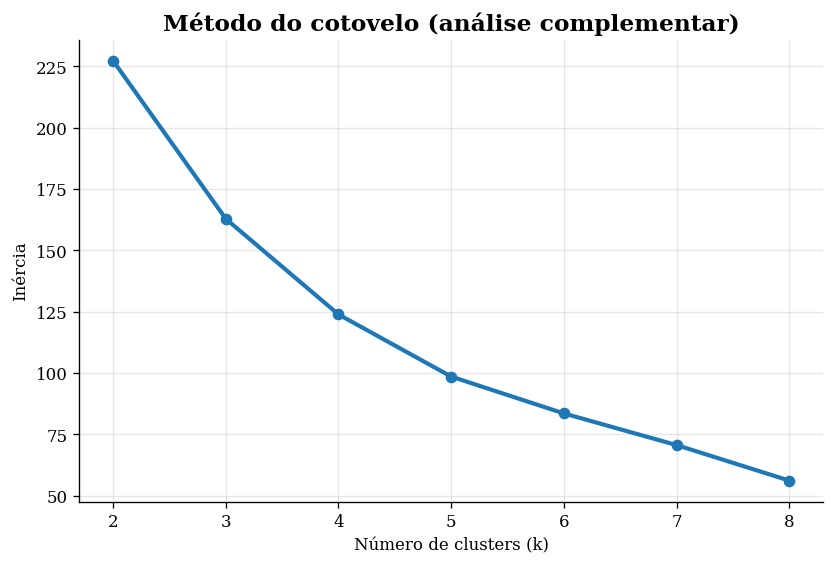

In [156]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao_k["k"],
    avaliacao_k["Inercia"],
    marker="o",
    linewidth=2.5
)

plt.title(
    "Método do cotovelo (análise complementar)",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")

plt.grid(alpha=0.3)

plt.show()

In [157]:
kmeans = KMeans(n_clusters=melhor_k, random_state=42, n_init=50)
nasc_uf["Cluster"] = kmeans.fit_predict(X_scaled)

nasc_uf["Queda_percentual"] = ((nasc_uf["2000"] - nasc_uf["2024"]) / nasc_uf["2000"]) * 100

ordem_clusters = (
    nasc_uf.groupby("Cluster")["Queda_percentual"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

mapa_clusters = {cluster_antigo: i + 1 for i, cluster_antigo in enumerate(ordem_clusters)}
nasc_uf["Cluster"] = nasc_uf["Cluster"].map(mapa_clusters)

resultado_clusters = nasc_uf[["UF", "Cluster"] + anos].copy()
resultado_clusters[["UF", "Cluster"]].sort_values(["Cluster", "UF"])

,UF,Cluster
2,Acre,1
6,Amapá,1
3,Amazonas,1
9,Maranhão,1
29,Mato Grosso,1
28,Mato Grosso do Sul,1
13,Paraíba,1
5,Pará,1
4,Roraima,1
15,Alagoas,2


In [158]:
tabela_estados_cluster = (
    resultado_clusters[["UF", "Cluster"]]
    .sort_values(["Cluster", "UF"])
    .rename(columns={"UF": "Estado"})
)

tabela_estados_cluster

,Estado,Cluster
2,Acre,1
6,Amapá,1
3,Amazonas,1
9,Maranhão,1
29,Mato Grosso,1
28,Mato Grosso do Sul,1
13,Paraíba,1
5,Pará,1
4,Roraima,1
15,Alagoas,2


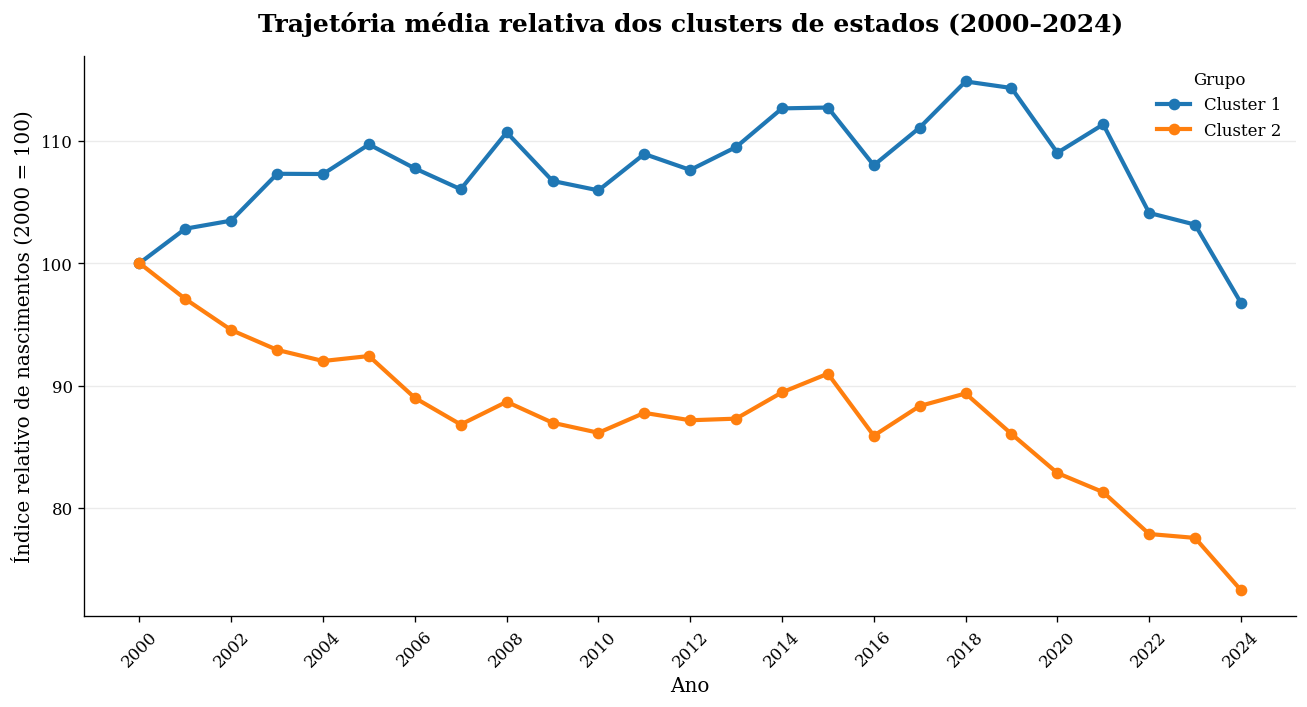

In [159]:
dados_relativos = X.copy()
dados_relativos["UF"] = nasc_uf["UF"].values
dados_relativos["Cluster"] = nasc_uf["Cluster"].values

cluster_medias = dados_relativos.groupby("Cluster")[anos].mean().reset_index()
cluster_long = cluster_medias.melt(id_vars="Cluster", var_name="Ano", value_name="Indice_relativo")
cluster_long["Ano"] = cluster_long["Ano"].astype(int)

plt.figure(figsize=(11, 6))
for cluster in sorted(cluster_long["Cluster"].unique()):
    temp = cluster_long[cluster_long["Cluster"] == cluster]
    plt.plot(temp["Ano"], temp["Indice_relativo"], marker="o", linewidth=2.5, label=f"Cluster {cluster}")

plt.title("Trajetória média relativa dos clusters de estados (2000–2024)", fontsize=15, weight="bold", pad=15)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Índice relativo de nascimentos (2000 = 100)", fontsize=12)
plt.xticks(range(2000, 2025, 2), rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Grupo", frameon=False)
plt.tight_layout()
plt.show()

In [160]:
resumo_por_cluster = (
    nasc_uf
    .groupby("Cluster")
    .agg(
        Numero_de_estados=("UF", "count"),
        Nascimentos_2000_media=("2000", "mean"),
        Nascimentos_2024_media=("2024", "mean"),
        Queda_percentual_media=("Queda_percentual", "mean")
    )
    .round(2)
    .reset_index()
)

resumo_por_cluster

,Cluster,Numero_de_estados,Nascimentos_2000_media,Nascimentos_2024_media,Queda_percentual_media
0,1,9,53489.11,50755.67,3.24
1,2,18,151408.83,107362.44,26.71


In [161]:
dados_mapa = ranking_queda.copy()

# Mostra os nomes das colunas
print(dados_mapa.columns)

# Usa a primeira coluna como nome dos estados
coluna_estado = dados_mapa.columns[0]

siglas_estados = {
    "Rondônia": "RO",
    "Acre": "AC",
    "Amazonas": "AM",
    "Roraima": "RR",
    "Pará": "PA",
    "Amapá": "AP",
    "Tocantins": "TO",
    "Maranhão": "MA",
    "Piauí": "PI",
    "Ceará": "CE",
    "Rio Grande do Norte": "RN",
    "Paraíba": "PB",
    "Pernambuco": "PE",
    "Alagoas": "AL",
    "Sergipe": "SE",
    "Bahia": "BA",
    "Minas Gerais": "MG",
    "Espírito Santo": "ES",
    "Rio de Janeiro": "RJ",
    "São Paulo": "SP",
    "Paraná": "PR",
    "Santa Catarina": "SC",
    "Rio Grande do Sul": "RS",
    "Mato Grosso do Sul": "MS",
    "Mato Grosso": "MT",
    "Goiás": "GO",
    "Distrito Federal": "DF"
}

dados_mapa["UF"] = dados_mapa[coluna_estado].map(siglas_estados)

mapa_brasil = read_state(year=2020)

mapa_brasil_cluster = mapa_brasil.merge(
    dados_mapa,
    left_on="abbrev_state",
    right_on="UF",
    how="left"
)

Index(['UF', '2000', '2024', 'Queda_absoluta', 'Queda_percentual'], dtype='object')


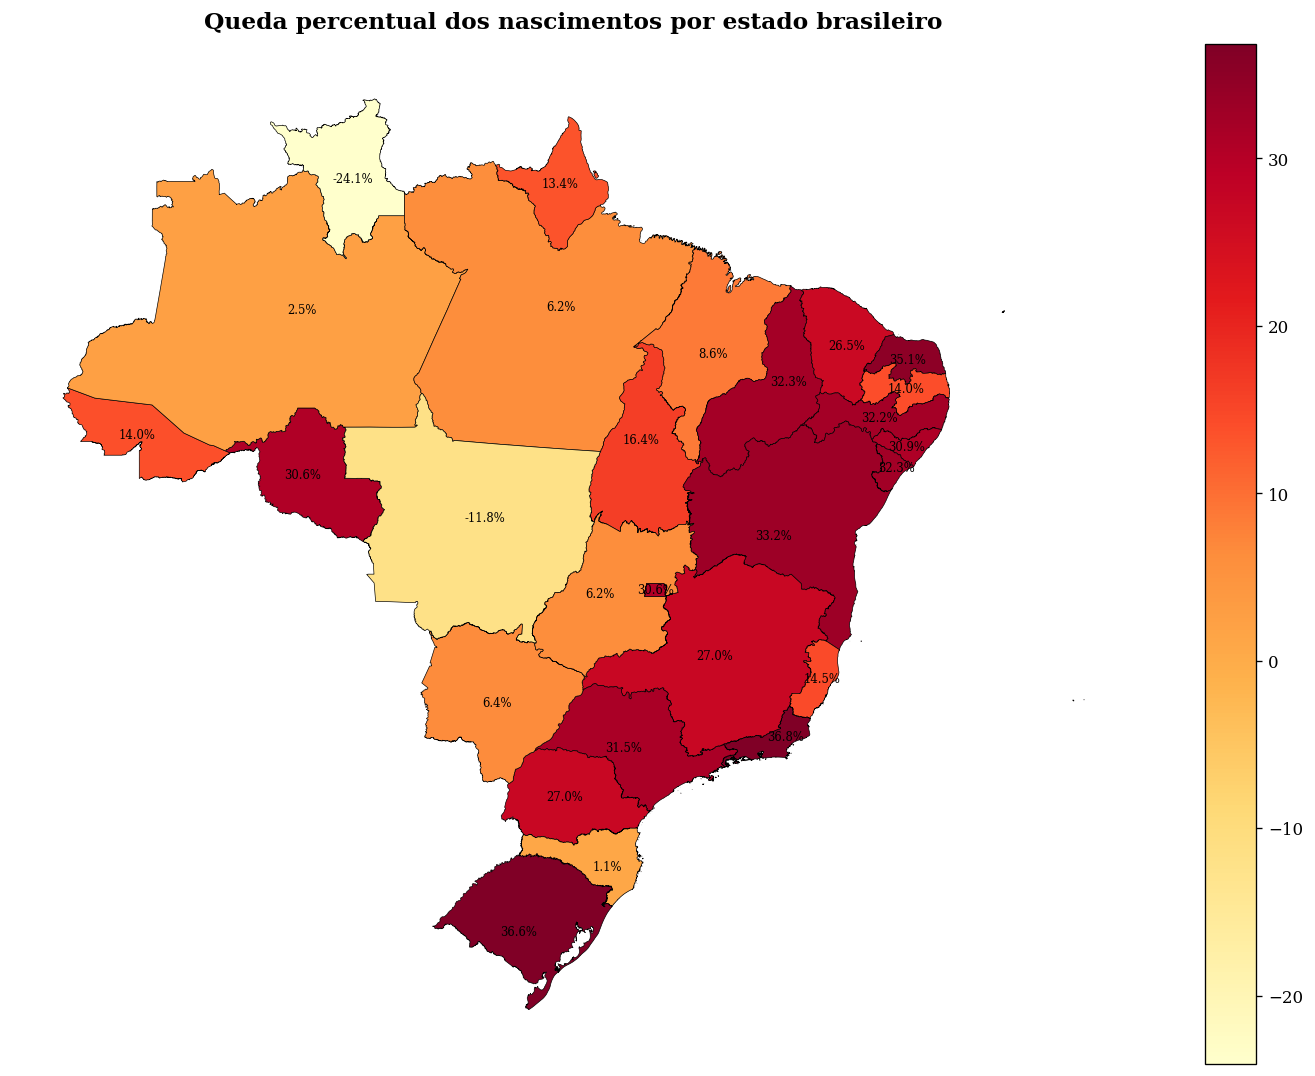

In [162]:
ax = mapa_brasil_cluster.plot(
    column="Queda_percentual",
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.4,
    figsize=(12, 9)
)

for idx, row in mapa_brasil_cluster.iterrows():
    if pd.notnull(row["Queda_percentual"]):
        ponto = row["geometry"].representative_point()
        ax.text(
            ponto.x,
            ponto.y,
            f'{row["Queda_percentual"]:.1f}%',
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

ax.set_title(
    "Queda percentual dos nascimentos por estado brasileiro",
    fontsize=14,
    weight="bold",
    pad=15
)

ax.axis("off")

plt.tight_layout()
plt.show()